# **4. Análisis de Promociones y Descuentos**

## **4.1 Panorama general de promociones**

In [5]:
from pathlib import Path
import pandas as pd

def find_project_root(start: Path, marker: str = "data", max_up: int = 6) -> Path:
    p = start.resolve()
    for _ in range(max_up):
        if (p / marker).exists():
            return p
        p = p.parent
    return start.resolve()

ROOT = find_project_root(Path.cwd())
DATA_PROCESSED = ROOT / "data" / "processed"

ts_path = DATA_PROCESSED / "ts_ventas_dia_tienda_producto.csv"

df_ts = pd.read_csv(ts_path, parse_dates=["FECHA"])

print("Shape:", df_ts.shape)
df_ts.head()

promo_summary = {
    "Total registros": len(df_ts),
    "Registros con promoción": int(df_ts["PROMO_FLAG_AGG"].sum()) if "PROMO_FLAG_AGG" in df_ts.columns else None,
    "Porcentaje con promoción": (
        df_ts["PROMO_FLAG_AGG"].mean() * 100
        if "PROMO_FLAG_AGG" in df_ts.columns else None
    ),
    "Descuento total": df_ts["DESCUENTO"].sum(),
    "Descuento promedio (%)": (
        (df_ts["DESCUENTO"] / df_ts["VENTA_BRUTA"]).mean() * 100
        if "VENTA_BRUTA" in df_ts.columns else None
    )
}

promo_summary

Shape: (228, 15)


{'Total registros': 228,
 'Registros con promoción': 24,
 'Porcentaje con promoción': np.float64(10.526315789473683),
 'Descuento total': np.float64(85309.0),
 'Descuento promedio (%)': np.float64(1.333619883416488)}

## **4.2 Frecuencia de promociones por producto y tienda**

In [6]:
promo_producto = (
    df_ts.groupby("PLU_SAP")["PROMO_FLAG_AGG"]
    .mean()
    .sort_values(ascending=False)
)

promo_producto.head(10)

PLU_SAP
27     1.0
41     1.0
98     1.0
73     1.0
126    1.0
189    1.0
181    1.0
124    1.0
133    1.0
383    1.0
Name: PROMO_FLAG_AGG, dtype: float64

## **4.3 Impacto de promoción en ventas netas**

In [7]:
impacto_promo = (
    df_ts.groupby("PROMO_FLAG_AGG")["VENTA_NETA"]
    .mean()
)

impacto_promo

PROMO_FLAG_AGG
0    24861.960784
1    22908.000000
Name: VENTA_NETA, dtype: float64

## **4.4 Comparación ventas con promoción vs sin promoción**

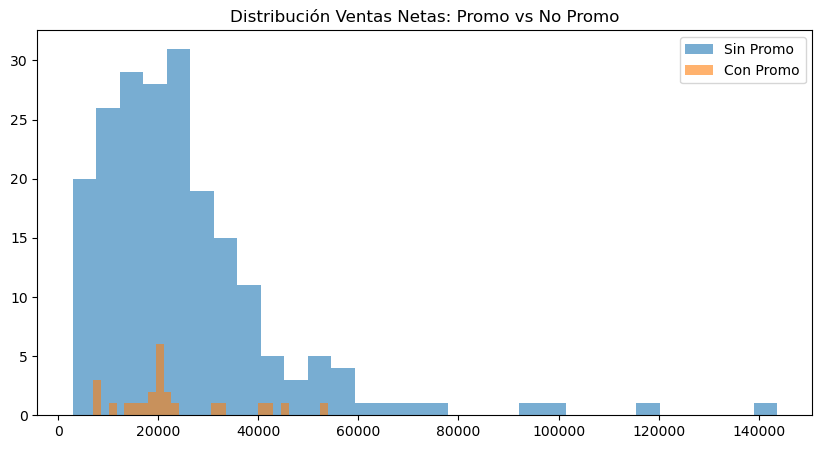

In [8]:
import matplotlib.pyplot as plt

ventas_promo = df_ts[df_ts["PROMO_FLAG_AGG"] == 1]["VENTA_NETA"]
ventas_no_promo = df_ts[df_ts["PROMO_FLAG_AGG"] == 0]["VENTA_NETA"]

plt.figure(figsize=(10,5))
plt.hist(ventas_no_promo, bins=30, alpha=0.6, label="Sin Promo")
plt.hist(ventas_promo, bins=30, alpha=0.6, label="Con Promo")
plt.legend()
plt.title("Distribución Ventas Netas: Promo vs No Promo")
plt.show()

## **4.5 Análisis del porcentaje de descuento**

In [9]:
df_ts["DESCUENTO_PCT_REAL"] = (
    df_ts["DESCUENTO"] / df_ts["VENTA_BRUTA"]
)

df_ts["DESCUENTO_PCT_REAL"].describe(percentiles=[0.1,0.25,0.5,0.75,0.9])

count    228.000000
mean       0.013336
std        0.048819
min        0.000000
10%        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
90%        0.028294
max        0.346287
Name: DESCUENTO_PCT_REAL, dtype: float64

## **4.6 Elasticidad aproximada precio–ventas (exploratorio)**

In [10]:
# Proxy de precio medio
df_ts["PRECIO_MEDIO_APROX"] = df_ts["VENTA_NETA"] / df_ts["UNIDADES"]

correlacion = df_ts[["PRECIO_MEDIO_APROX", "VENTA_NETA"]].corr()

correlacion

,PRECIO_MEDIO_APROX,VENTA_NETA
PRECIO_MEDIO_APROX,1.000000,0.196395
VENTA_NETA,0.196395,1.000000


## **4.7 Distribución del descuento aplicado**

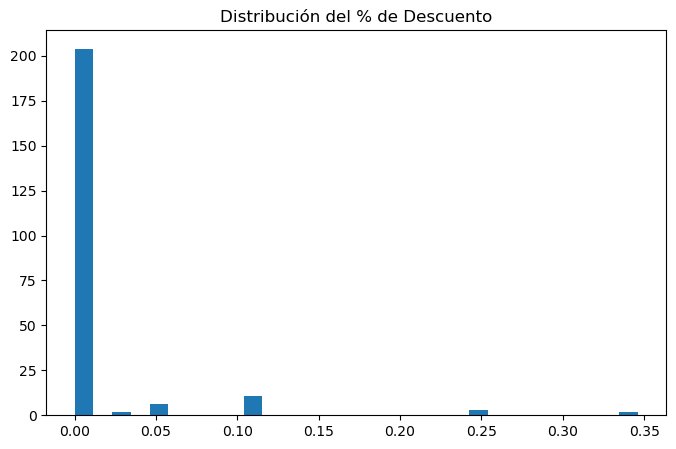

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df_ts["DESCUENTO_PCT_REAL"].dropna(), bins=30)
plt.title("Distribución del % de Descuento")
plt.show()

## **4.8 Productos más sensibles a promociones**

In [12]:
sensibilidad = (
    df_ts.groupby(["PLU_SAP", "PROMO_FLAG_AGG"])["VENTA_NETA"]
    .mean()
    .unstack()
)

sensibilidad["Lift_Promo"] = sensibilidad[1] - sensibilidad[0]
sensibilidad = sensibilidad.sort_values("Lift_Promo", ascending=False)

sensibilidad.head(10)

PROMO_FLAG_AGG,0,1,Lift_Promo
PLU_SAP,,,
3,36900.0,NaN,NaN
5,143700.0,NaN,NaN
7,60900.0,NaN,NaN
9,17750.0,NaN,NaN
11,24300.0,NaN,NaN
13,7200.0,NaN,NaN
15,17980.0,NaN,NaN
17,23700.0,NaN,NaN
19,31400.0,NaN,NaN


## **4.9 Conclusiones estratégicas sobre promociones**

In [13]:
conclusiones_promo = {
    "Venta promedio con promo": float(ventas_promo.mean()) if len(ventas_promo)>0 else None,
    "Venta promedio sin promo": float(ventas_no_promo.mean()) if len(ventas_no_promo)>0 else None,
    "Lift promedio aproximado": float(ventas_promo.mean() - ventas_no_promo.mean()) if len(ventas_promo)>0 else None,
    "Correlación precio–ventas": float(correlacion.iloc[0,1]) if correlacion is not None else None,
}

conclusiones_promo

{'Venta promedio con promo': 22908.0,
 'Venta promedio sin promo': 24861.960784313724,
 'Lift promedio aproximado': -1953.9607843137237,
 'Correlación precio–ventas': 0.19639542670916246}